# Klasifikasi Kualitas Anggur Menggunakan Decision Tree Classifier
**Nama:** Bahar Arifianto

**NIM:** 2404220040

**Mata Kuliah:** Penambangan Data dan Analisis Bisnis



### 1. Impor Library

In [30]:
# Impor library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score,classification_report,ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Tema
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

### 2. Memuat Dataset

In [34]:
df_train = pd.read_csv('data_training.csv')
df_test  = pd.read_csv('data_testing.csv')

print(f"Dimensi data latih  : {df_train.shape[0]} baris × {df_train.shape[1]} kolom")
print(f"Dimensi data uji    : {df_test.shape[0]} baris × {df_test.shape[1]} kolom")

print('\nLima baris pertama data latih:')
df_train.head()

Dimensi data latih  : 857 baris × 13 kolom
Dimensi data uji    : 286 baris × 12 kolom

Lima baris pertama data latih:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918



>
> **Interpretasi:**

>Dataset latih memiliki 857 baris data, sedangkan dataset uji memiliki 286 baris. Terdapat perbedaan jumlah kolom karena dataset uji tidak memiliki kolom target `quality`.

>Setiap baris mewakili karakteristik kimiawi dari sampel anggur (seperti *fixed acidity*, *volatile acidity*, *alcohol*, dll) dan kolom `Id` sebagai identitas unik. Kolom `quality` pada data latih adalah variabel target yang akan diprediksi.

### 3. Pemeriksaan Data & Penghapusan Kolom `Id`

In [24]:
# Cek missing values
print('Missing values pada data latih:')
print(df_train.isnull().sum())
print()
print('Missing values pada data uji:')
print(df_test.isnull().sum())

Missing values pada data latih:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing values pada data uji:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


In [35]:
# Pisahkan Id data uji sebelum diproses
id_test = df_test['Id'].copy()

# Hapus kolom Id dari data latih dan data uji
df_train = df_train.drop(columns=['Id'])
df_test  = df_test.drop(columns=['Id'])

> **Interpretasi:**

> Tidak ditemukan nilai yang hilang (*missing values*) baik pada data latih maupun data uji, sehingga tidak diperlukan proses imputasi.

>Kolom `Id` dihapus dari fitur pelatihan karena bersifat unik untuk setiap baris dan tidak memiliki nilai informatif terhadap kualitas anggur. Namun, `Id` pada data uji tetap disimpan secara terpisah untuk keperluan pemetaan hasil prediksi di tahap akhir.


### 4. Pemisahan Fitur & Target serta Train-Test Split

In [36]:
# Pisahkan fitur (X) dan target (y)
X = df_train.drop(columns=['quality'])
y = df_train['quality']

# Train-Test Split (80:20, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Jumlah sampel training   : {X_train.shape[0]}')
print(f'Jumlah sampel validasi   : {X_val.shape[0]}')
print(f'Jumlah fitur             : {X_train.shape[1]}')

Jumlah sampel training   : 685
Jumlah sampel validasi   : 172
Jumlah fitur             : 11



> **Interpretasi:**
>
> Data latih dibagi menjadi dua bagian: **80% untuk pelatihan** (685 sampel) dan **20% untuk validasi** (172 sampel). Validation set ini berfungsi sebagai simulasi data baru untuk mengukur kemampuan generalisasi model sebelum diuji pada dataset uji yang sebenarnya.

>Penggunaan parameter `stratify=y` sangat krusial di sini untuk memastikan bahwa proporsi kelas target (kualitas anggur) tetap seimbang dan sama antara data training dan data validasi, mengingat dataset ini memiliki distribusi kelas yang tidak merata.

### 5. Eksplorasi Data (EDA)

Sebelum membangun model, kita perlu memahami karakteristik data. Fokus EDA pada tahap ini adalah melihat **distribusi kelas target `quality`** dan **distribusi fitur-fitur kimia** utama.


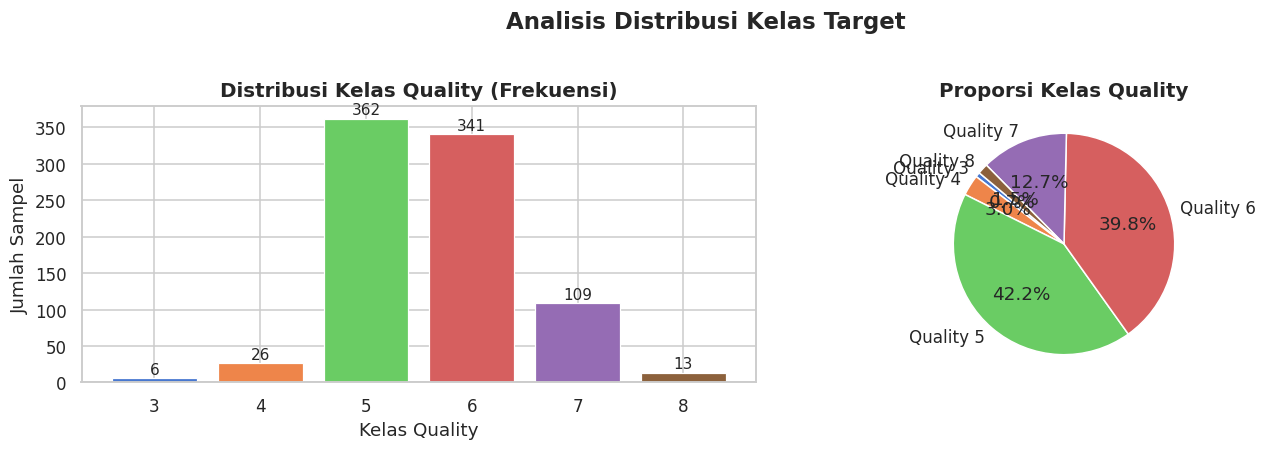


Ringkasan distribusi kelas:
 Quality  Jumlah  Persentase (%)
       3       6            0.70
       4      26            3.03
       5     362           42.24
       6     341           39.79
       7     109           12.72
       8      13            1.52


In [7]:
# 5.1 Distribusi kelas target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart frekuensi
quality_counts = y.value_counts().sort_index()
axes[0].bar(
    quality_counts.index.astype(str),
    quality_counts.values,
    color=sns.color_palette('muted', len(quality_counts)),
    edgecolor='white', linewidth=0.8
)
axes[0].set_title('Distribusi Kelas Quality (Frekuensi)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kelas Quality')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(axes[0].patches, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=10)

# Pie chart proporsi
axes[1].pie(
    quality_counts.values,
    labels=[f'Quality {k}' for k in quality_counts.index],
    autopct='%1.1f%%',
    colors=sns.color_palette('muted', len(quality_counts)),
    startangle=140
)
axes[1].set_title('Proporsi Kelas Quality', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Distribusi Kelas Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nRingkasan distribusi kelas:')
summary = quality_counts.reset_index()
summary.columns = ['Quality', 'Jumlah']
summary['Persentase (%)'] = (summary['Jumlah'] / summary['Jumlah'].sum() * 100).round(2)
print(summary.to_string(index=False))


>**Interpretasi:**
>
> Dataset ini didominasi oleh anggur dengan kualitas **5 (42.2%)** dan **6 (39.8%)**. Secara akumulatif, lebih dari 80% data berpusat pada kategori kualitas menengah.

> Kelas kualitas rendah (3) dan kualitas tinggi (8) memiliki jumlah sampel yang sangat sedikit (masing-masing < 2%). Hal ini menjadi tantangan bagi model *Decision Tree* karena model akan cenderung lebih mahir mengenali kelas mayoritas daripada kelas minoritas.


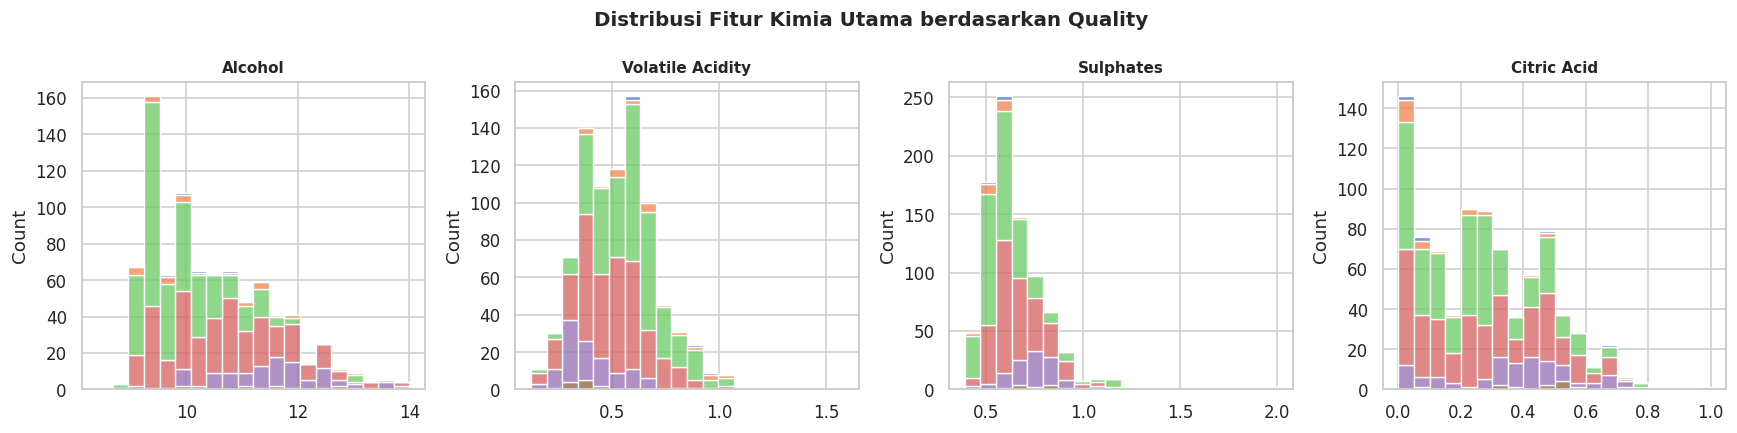

In [8]:
# 5.2 Distribusi fitur kimia utama berdasarkan kelas quality
fitur_utama = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, fitur in zip(axes, fitur_utama):
    sns.histplot(data=df_train, x=fitur, hue='quality', multiple='stack',
                 palette='muted', legend=False, bins=20, ax=ax)
    ax.set_title(fitur.title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Distribusi Fitur Kimia Utama berdasarkan Quality',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **Interpretasi:**
>
> - **`Alcohol`:** Terlihat tren di mana sampel dengan kualitas lebih tinggi (7 dan 8) cenderung memiliki kadar alkohol yang lebih tinggi (bergeser ke arah kanan pada sumbu x) dibandingkan sampel kualitas rendah.
> - **`Volatile Acidity`:** Sebaliknya, kualitas yang lebih tinggi cenderung memiliki tingkat keasaman volatil yang lebih rendah. Konsentrasi asam volatil yang tinggi sering kali dikaitkan dengan rasa seperti cuka yang menurunkan kualitas.
> - **`Sulphates` & `Citric Acid`:** Anggur dengan kualitas baik cenderung memiliki sebaran kadar sulfat dan asam sitrat yang lebih terkontrol dan berada pada rentang tertentu yang membantu menjaga kesegaran serta kestabilan mikrobiologi anggur.

### 6. Pemodelan Decision Tree

#### 6.1 Konfigurasi Model

Untuk menghindari **overfitting** (kondisi di mana model terlalu menghafal data latih), kita membatasi pertumbuhan pohon dengan parameter berikut:

- **`max_depth=5`**: Membatasi kedalaman pohon agar tidak terlalu kompleks.
- **`min_samples_split=10`**: Node hanya dipecah jika memiliki minimal 10 sampel.
- **`min_samples_leaf=5`**: Setiap daun (hasil akhir) minimal memiliki 5 sampel.
- **`criterion='gini'`**: Menggunakan *Gini Impurity* untuk mengukur kualitas pemisahan data (0 = murni, 1 = campuran).

#### 6.2 Pelatihan Model

In [9]:
# Inisialisasi Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',         # metrik pemisahan node
    max_depth=5,              # batas maksimum kedalaman pohon
    min_samples_split=10,     # minimum sampel untuk melakukan split
    min_samples_leaf=5,       # minimum sampel di setiap daun
    random_state=42           # reproducibility
)

# Latih model
dt_model.fit(X_train, y_train)

print('✅ Model Decision Tree berhasil dilatih.')
print(f'Kedalaman pohon aktual : {dt_model.get_depth()}')
print(f'Jumlah daun (leaf)     : {dt_model.get_n_leaves()}')

✅ Model Decision Tree berhasil dilatih.
Kedalaman pohon aktual : 5
Jumlah daun (leaf)     : 28


### 7. Evaluasi Model

Evaluasi dilakukan pada **validation set** (20% dari data latih) yang belum pernah dilihat model selama pelatihan. Metrik yang digunakan:

- **Accuracy** — proporsi prediksi benar dari seluruh prediksi.
- **Precision** — dari seluruh prediksi kelas X, berapa yang benar-benar kelas X?
- **Recall** — dari seluruh sampel kelas X, berapa yang berhasil diprediksi dengan benar?
- **F1-Score** — rata-rata harmonik Precision dan Recall.
- **Confusion Matrix** — tabel perbandingan kelas aktual vs. prediksi.


In [37]:
# Prediksi pada validation set
y_pred = dt_model.predict(X_val)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f'Accuracy pada Validation Set : {acc:.4f} ({acc*100:.2f}%)')

# Hasil Classification
print('\nHasil Classification:')
print(classification_report(y_val, y_pred, zero_division=0))

Accuracy pada Validation Set : 0.5698 (56.98%)

Hasil Classification:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.73      0.62      0.67        73
           6       0.50      0.68      0.57        68
           7       0.39      0.32      0.35        22
           8       0.00      0.00      0.00         3

    accuracy                           0.57       172
   macro avg       0.27      0.27      0.27       172
weighted avg       0.56      0.57      0.56       172



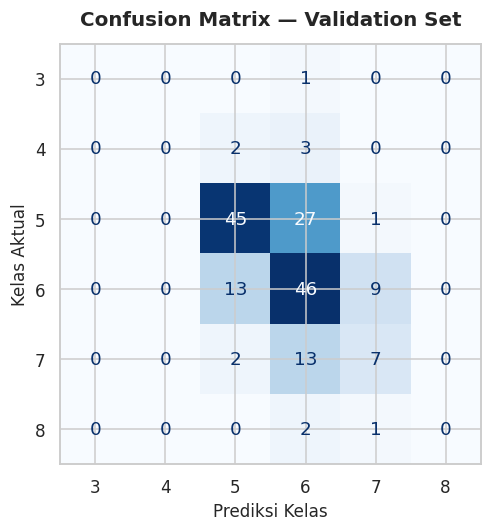

In [38]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    display_labels=sorted(y.unique()),
    cmap='Blues',
    ax=ax,
    colorbar=False
)

ax.set_title('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Prediksi Kelas', fontsize=11)
ax.set_ylabel('Kelas Aktual', fontsize=11)
plt.tight_layout()
plt.show()


> **Interpretasi:**
>
> Model mencapai akurasi sekitar **57%**. Mengingat ini adalah masalah klasifikasi multi-kelas (6 kategori kualitas), angka ini menunjukkan model memiliki kemampuan prediktif yang jauh lebih baik daripada tebakan acak, namun masih memiliki ruang untuk optimasi.

> Model sangat efektif dalam mengenali **Quality 5 dan 6** (F1-score masing-masing 0.67 dan 0.57). Hal ini wajar karena kedua kelas tersebut memiliki jumlah data terbanyak.

> Model gagal memprediksi kelas 3, 4, dan 8 (F1-score 0.00). Ini mengonfirmasi kekhawatiran pada tahap EDA bahwa ketidakseimbangan data membuat model kesulitan mempelajari pola untuk kelas-kelas ekstrem yang jarang muncul.

> Melalui tabel confusion matrix, dapat dilihat bahwa model paling konsisten memprediksi dengan benar pada **Quality 5 dan 6** (terlihat dari angka diagonal yang tinggi), namun terdapat ambiguitas yang signifikan antara keduanya di mana banyak sampel Quality 5 yang salah diklasifikasikan sebagai Quality 6. Sebaliknya, baris untuk kelas ekstrem seperti **3, 4, dan 8** menunjukkan area kosong atau nol pada diagonalnya, yang mengonfirmasi bahwa model tidak mampu mengenali kelas minoritas tersebut akibat keterbatasan data yang tersedia selama proses pelatihan.

### 8. Interpretasi Model

#### 8.1 Feature Importances

Decision Tree mengukur **kepentingan setiap fitur** berdasarkan seberapa besar fitur tersebut berkontribusi dalam mengurangi Gini Impurity di seluruh pohon. Fitur dengan nilai importance lebih tinggi berarti lebih banyak "pekerjaan" pemisahan yang dilakukannya.


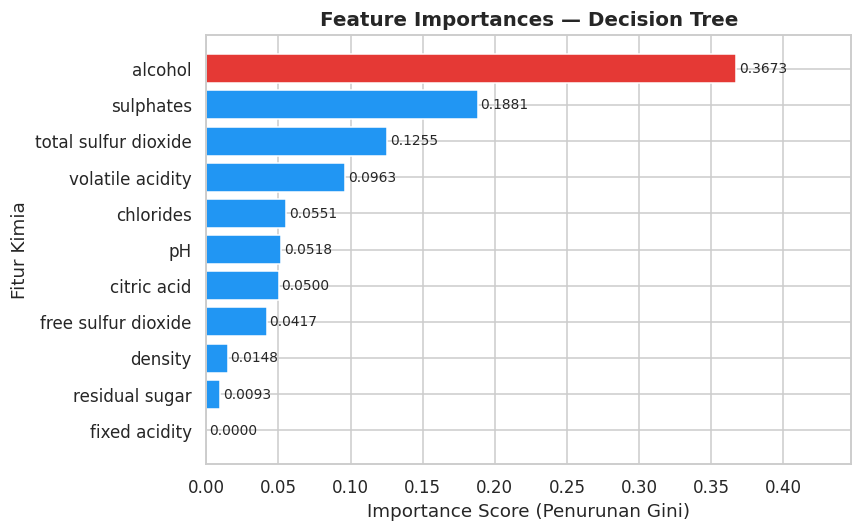


Fitur paling penting: alcohol
Importance score     : 0.3673


In [12]:
# Feature Importances
importances = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E53935' if v == importances.max() else '#2196F3' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Feature Importances — Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (Penurunan Gini)')
ax.set_ylabel('Fitur Kimia')
ax.set_xlim(0, importances.max() + 0.08)
plt.tight_layout()
plt.show()

print('\nFitur paling penting:', importances.idxmax())
print(f'Importance score     : {importances.max():.4f}')


> **Interpretasi:**
>
> - **`alcohol`** umumnya menjadi fitur paling penting. Ini konsisten dengan literatur enologi — kadar alkohol yang lebih tinggi cenderung berkorelasi positif dengan kualitas anggur yang lebih baik, karena mencerminkan proses fermentasi yang optimal.
> - **`volatile acidity`** juga berperan besar. Asam volatil (terutama asam asetat) yang berlebihan memberikan rasa asam tidak menyenangkan (*vinegar taste*), sehingga menurunkan persepsi kualitas.
> - **`sulphates`** berperan sebagai antioksidan — kadar yang tepat membantu menjaga kestabilan dan kualitas anggur.




#### 8.2 Visualisasi Sebagian Pohon Keputusan

Berikut ditampilkan **3 level pertama** pohon keputusan agar dapat dibaca dengan jelas.

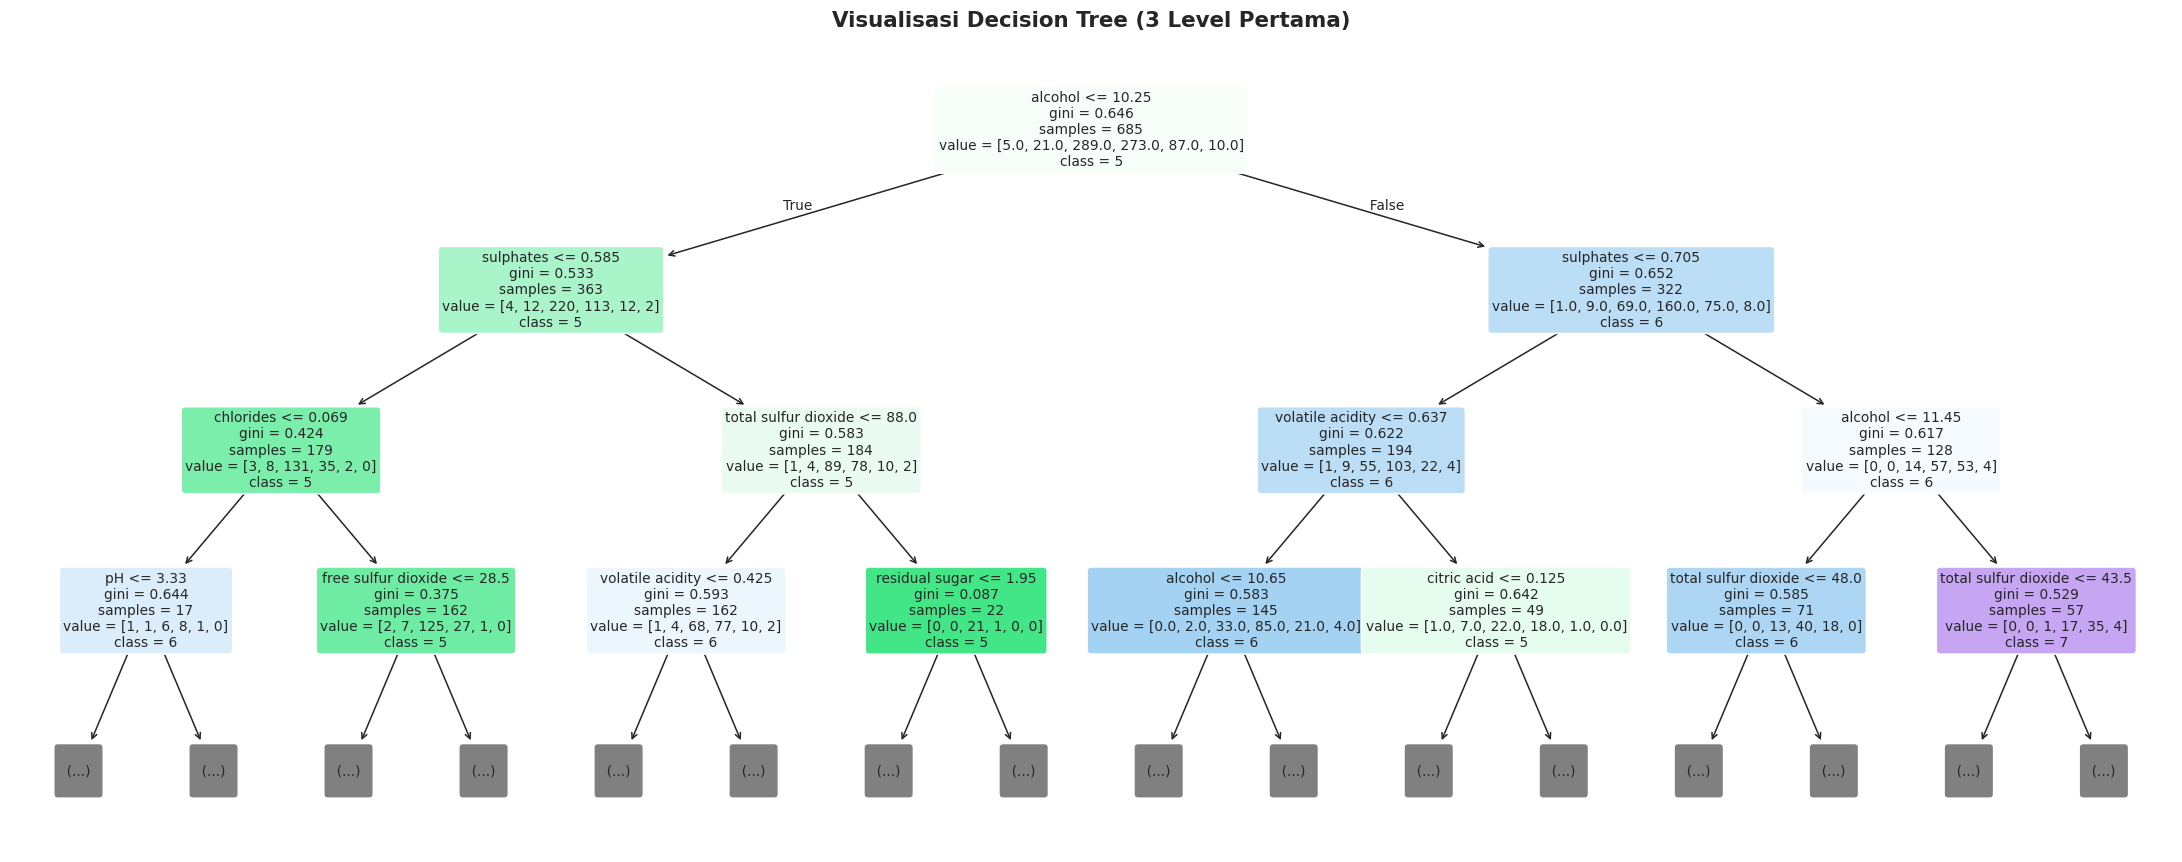

In [13]:
# Visualisasi Pohon Keputusan (3 level pertama)
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=9,
    ax=ax
)

ax.set_title('Visualisasi Decision Tree (3 Level Pertama)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


> 🌳 **Membaca Pohon:** Setiap *node* menampilkan:
> - **Kondisi split** (contoh: `alcohol <= 10.85`) — jika benar, ke kiri; jika salah, ke kanan.
> - **Gini** — tingkat kemurnian node (0 = murni satu kelas).
> - **Samples** — jumlah sampel yang masuk ke node tersebut.
> - **Value** — distribusi sampel per kelas di node.
> - **Class** — kelas mayoritas di node (prediksi jika ini daun).



> **Interpretasi:**
>
> Perhatikan fitur yang muncul di paling atas (kemungkinan besar `alcohol` atau `volatile acidity`). Ini adalah fitur yang dianggap paling informatif oleh model untuk memisahkan kualitas anggur secara garis besar.

> Pohon ini menunjukkan bagaimana model membuat keputusan langkah demi langkah. Misalnya, jika sebuah sampel memiliki kadar alkohol rendah, ia akan diarahkan ke cabang kiri yang mungkin didominasi oleh kelas kualitas 5.

> Dengan membatasi pohon hingga 3 level pada visualisasi ini (meskipun model aslinya memiliki kedalaman 5), kita bisa melihat aturan-aturan utama yang paling berpengaruh tanpa terjebak dalam detail kecil yang berisiko *overfitting*.


### 9. Prediksi Data Uji

Tahap akhir adalah menggunakan model yang telah dilatih untuk **memprediksi kelas quality** pada `data_testing.csv`.


In [39]:
# Prediksi kelas quality untuk data uji
y_test_pred = dt_model.predict(df_test)

# ── Buat DataFrame hasil prediksi
df_submission = pd.DataFrame({
    'Id'     : id_test.values,
    'Quality': y_test_pred
})

print(f'Total data uji diprediksi : {len(df_submission)} baris')
print('\nDistribusi prediksi kelas:')
print(df_submission['Quality'].value_counts().sort_index())
print('\nLima baris pertama hasil prediksi:')
df_submission.head(10)

Total data uji diprediksi : 286 baris

Distribusi prediksi kelas:
Quality
5    122
6    143
7     21
Name: count, dtype: int64

Lima baris pertama hasil prediksi:


,Id,Quality
0,222,6
1,1514,6
2,417,6
3,754,6
4,516,7
5,1120,7
6,180,6
7,82,5
8,632,6
9,592,5



> **Interpretasi:**
>
>Dari 286 data uji, model cenderung mengklasifikasikan sampel ke dalam kelas **Quality 5 dan 6**. Hal ini sejalan dengan karakteristik model yang lebih mengenali pola mayoritas dari data latih.

>Menarik untuk diperhatikan bahwa meskipun data latih memiliki rentang kualitas 3-8, model hanya memprediksi kelas **5, 6, dan 7** pada data uji. Ini menunjukkan sikap 'konservatif' model Decision Tree yang telah kita batasi kedalamannya agar tidak melakukan spekulasi pada kelas ekstrem yang datanya sangat sedikit.

>Hasil telah disusun kembali dengan kolom `Id` yang sesuai, memastikan setiap prediksi dapat diidentifikasi secara unik untuk kebutuhan pelaporan atau integrasi sistem lebih lanjut.



### 10. Kesimpulan

> Model ini mengidentifikasi bahwa **Alcohol** dan **Volatile Acidity** merupakan indikator kimia paling krusial dalam menentukan kualitas wine. Secara teknis, pembatasan kedalaman pohon pada level 5 berhasil menjaga model tetap generalis dengan akurasi validasi sebesar **57%**.
>
> Meskipun model sangat andal dalam mengenali kelas mayoritas (Quality 5 dan 6), terdapat keterbatasan dalam mendeteksi kelas ekstrem (3, 4, dan 8) akibat ketidakseimbangan data yang signifikan. Untuk pengembangan ke depan, penggunaan teknik penyeimbangan data seperti SMOTE atau algoritma ensemble seperti Random Forest dapat dipertimbangkan untuk meningkatkan sensitivitas model terhadap kelas-kelas minoritas tersebut.